In [7]:
# ==========================================================
# ADIM 1: Gerekli Kütüphaneler
# ==========================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from collections import Counter
import numpy as np
import sys

print("Adım 1: Kütüphaneler yüklendi.")


# ==========================================================
# ADIM 2: Model Mimarisi (TextCNN Sınıfı)
# ==========================================================
# Slayt 11-15'teki CNN mimarisi
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes,
                 num_filters=100, filter_sizes=[3, 4, 5]):

        super(TextCNN, self).__init__()

        # Slayt 11, Adım 1: "Embed words"
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Slayt 11, Adım 2: "Apply filters"
        # Slayt 13-14: Farklı "Scanner" ve "Filter"lar
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim,
                      out_channels=num_filters,
                      kernel_size=fs)
            for fs in filter_sizes
        ])

        # Slayt 11, Adım 4: "Classify"
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        embedded = self.embedding(x)  # [B, L] -> [B, L, D]
        embedded = embedded.permute(0, 2, 1) # [B, L, D] -> [B, D, L]

        conved = [F.relu(conv(embedded)) for conv in self.convs]

        # Slayt 11, Adım 3 & Slayt 15: "Max pooling"
        pooled = [F.max_pool1d(c, c.shape[2]).squeeze(2) for c in conved]

        cat = torch.cat(pooled, dim=1)
        cat = self.dropout(cat)
        output = self.fc(cat)
        return output

print("Adım 2: TextCNN model sınıfı (mimarisi) tanımlandı.")
print("--- Bu bloğu çalıştırdıktan sonra Adım 3+4 bloğuna geçebilirsiniz ---")

Adım 1: Kütüphaneler yüklendi.
Adım 2: TextCNN model sınıfı (mimarisi) tanımlandı.
--- Bu bloğu çalıştırdıktan sonra Adım 3+4 bloğuna geçebilirsiniz ---


In [8]:
# ==========================================================
# ADIM 3: Veri Yükleme, İşleme ve Sözlük (Vocabulary) Oluşturma
# ==========================================================
# Bu adım, 'clean_data222.csv' dosyasını CNN için hazırlar.

yerel_dosya_yolu = "/content/drive/MyDrive/Colab Notebooks/clean_data222.csv" # Sizin NB kodunuzdaki dosya adı
TEXT_COLUMN = 'text'
LABEL_COLUMN = 'label'

try:
    print(f"Adım 3: '{yerel_dosya_yolu}' dosyasından veri seti yükleniyor...")
    df = pd.read_csv(yerel_dosya_yolu)

    # Sizin NB kodunuzdaki gibi 'clean_content' sütununu 'text' olarak yeniden adlandıralım
    if 'clean_content' in df.columns:
        print("'clean_content' sütunu 'text' olarak yeniden adlandırılıyor...")
        df.rename(columns={'clean_content': 'text'}, inplace=True)

    # 'Science' filtresi uygulanmıyor, tüm 6 sınıf kullanılıyor.
    print(f"Veri boyutu (filtresiz): {df.shape}")

    # 1. Etiketleri Metinden Tamsayıya Dönüştürme (6 Sınıf için)
    # PyTorch CrossEntropyLoss, 'Politics', 'Science' yerine 0, 1, 2... bekler
    labels_list = sorted(df[LABEL_COLUMN].unique())
    label_to_int = {label: i for i, label in enumerate(labels_list)}
    df['label_int'] = df[LABEL_COLUMN].map(label_to_int)

    # Bu değişkenler Adım 6'da modele verilecek
    num_classes = len(label_to_int) # Toplam sınıf sayısı (6)

    print(f"\n{num_classes} sınıf bulundu ve sayısallaştırıldı:")
    print(label_to_int)
    print("-" * 30)

    # 2. Veriyi Eğitim ve Test Setlerine Ayırma
    X = df[TEXT_COLUMN].fillna('').values # NaN hatalarını önle
    y = df['label_int'].values

    # stratify=y: Sizin NB kodunuzdaki gibi 6 sınıfın oranını korur
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print(f"Eğitim Seti (X_train) Boyutu: {len(X_train)}")
    print(f"Test Seti (X_test) Boyutu: {len(X_test)}")
    print("-" * 30)

    # 3. Sözlük (Vocabulary) Oluşturma (TF-IDF YERİNE)
    print("Eğitim verisinden (X_train) sözlük (vocabulary) oluşturuluyor...")
    vocab_counter = Counter()
    for text in X_train:
        vocab_counter.update(str(text).lower().split())

    # Sizin NB kodunuzdaki max_features=20000 ayarına benzer bir sınır
    max_vocab_size = 20000

    # Kelimeleri indekslere (sayılara) eşleştirelim
    word2idx = {word: i+2 for i, (word, count) in enumerate(vocab_counter.most_common(max_vocab_size))}
    word2idx['<PAD>'] = 0 # Padding (Doldurma) için özel token
    word2idx['<UNK>'] = 1 # Unknown (Bilinmeyen kelime) için özel token

    # Bu değişken Adım 6'da modele verilecek
    vocab_size = len(word2idx)

    print(f"Sözlük (Vocabulary) oluşturuldu. Boyut: {vocab_size} kelime")
    print("Veri hazırlama (Adım 3) tamamlandı.")


except Exception as e:
    print(f"\n\nHATA: Veri işlenirken bir sorun oluştu: {e}")
    # Hata durumunda script'i durdur (eğer script olarak çalışıyorsa)
    # sys.exit(1)


# ==========================================================
# ADIM 4: Veriyi PyTorch'a Hazırlama (Dataset Sınıfı)
# ==========================================================
# Hocanın kodundaki IMDBDataset veya MovieDataset sınıfına benzer

class NewsDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=150):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len
        self.unknown_idx = word2idx['<UNK>'] # 1
        self.pad_idx = word2idx['<PAD>']     # 0

    def __len__(self):
        # Toplam veri sayısını döndürür
        return len(self.texts)

    def __getitem__(self, idx):
        # Bir adet veri (idx) istendiğinde bu fonksiyon çalışır

        # 1. Metni ve etiketi al
        text = str(self.texts[idx])
        label = self.labels[idx]

        # 2. Metni kelimelere ayır ve sayısallaştır
        indices = []
        for word in text.lower().split():
            # Kelime sözlükte varsa indeksini al, yoksa <UNK> indeksini (1) al
            idx_num = self.word2idx.get(word, self.unknown_idx)
            indices.append(idx_num)

        # 3. Doldurma (Padding) veya Kırpma (Truncating)
        # CNN'ler (Slayt 11) ve hocanın kodu sabit boyutlu girdi bekler.
        if len(indices) < self.max_len:
            # Cümle kısaysa, sonuna <PAD> (0) indeksi ekle
            indices += [self.pad_idx] * (self.max_len - len(indices))
        else:
            # Cümle uzunsa, max_len'e göre kırp
            indices = indices[:self.max_len]

        # 4. Veriyi PyTorch tensörlerine dönüştür
        indices_tensor = torch.tensor(indices, dtype=torch.long)
        label_tensor = torch.tensor(label, dtype=torch.long)

        return indices_tensor, label_tensor

# --- Test ---
try:
    print("\nAdım 4: NewsDataset sınıfı oluşturuluyor...")
    # max_len=150 (CNN için genellikle 50-200 arası iyidir)
    train_dataset = NewsDataset(X_train, y_train, word2idx, max_len=150)
    test_dataset = NewsDataset(X_test, y_test, word2idx, max_len=150)

    # Bir adet örnek alıp bakalım:
    sample_text, sample_label = train_dataset[0]
    print(f"\nEğitim setinden ilk örnek (sayısallaştırılmış):")
    print(f"Metin Tensörü (shape: {sample_text.shape})") # [150] olmalı
    print(f"Etiket Tensörü (int): {sample_label}") # 0-5 arası bir sayı olmalı
    print("\n--- Adım 3 ve 4 başarıyla tamamlandı. Şimdi Adım 5'e geçebilirsiniz. ---")

except NameError:
    print("\n--- HATA ---")
    print("Bu bloğu çalıştırdıktan sonra hala NameError alıyorsanız, lütfen Adım 3'teki CSV okuma adımının başarılı olduğundan emin olun.")
except Exception as e:
    print(f"\nBir hata oluştu: {e}")

Adım 3: '/content/drive/MyDrive/Colab Notebooks/clean_data222.csv' dosyasından veri seti yükleniyor...
'clean_content' sütunu 'text' olarak yeniden adlandırılıyor...
Veri boyutu (filtresiz): (136124, 2)

6 sınıf bulundu ve sayısallaştırıldı:
{'Emotion': 0, 'Financial': 1, 'Health': 2, 'Politics': 3, 'Science': 4, 'Sport': 5}
------------------------------
Eğitim Seti (X_train) Boyutu: 108899
Test Seti (X_test) Boyutu: 27225
------------------------------
Eğitim verisinden (X_train) sözlük (vocabulary) oluşturuluyor...
Sözlük (Vocabulary) oluşturuldu. Boyut: 20002 kelime
Veri hazırlama (Adım 3) tamamlandı.

Adım 4: NewsDataset sınıfı oluşturuluyor...

Eğitim setinden ilk örnek (sayısallaştırılmış):
Metin Tensörü (shape: torch.Size([150]))
Etiket Tensörü (int): 2

--- Adım 3 ve 4 başarıyla tamamlandı. Şimdi Adım 5'e geçebilirsiniz. ---


In [9]:
# ==========================================================
# ADIM 5: DataLoader'ların Oluşturulması
# ==========================================================
# Bu adım, hocanın kodundaki train_loader = DataLoader(...) satırlarına karşılık gelir.
# Adım 3+4'te oluşturulan 'train_dataset' ve 'test_dataset' değişkenlerini kullanır.

try:
    # Mini-grup (batch) boyutunu belirleyelim
    # Bu, her eğitim adımında modele aynı anda kaç örnek verileceğini belirler.
    # 32 veya 64, GPU belleğine bağlı olarak iyi bir başlangıçtır.
    BATCH_SIZE = 32

    # Eğitim verisi için DataLoader
    # dataset=train_dataset: Adım 4'te oluşturduğumuz sınıfı kullanır.
    # shuffle=True: Her eğitim turunda (epoch) veriyi karıştırır.
    # Bu, modelin ezberlemesini önler ve daha iyi öğrenmesini sağlar.
    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    # Test verisi için DataLoader
    # dataset=test_dataset: Adım 4'te oluşturduğumuz sınıfı kullanır.
    # shuffle=False: Test ederken veriyi karıştırmaya gerek yoktur,
    # performansı tutarlı bir şekilde ölçmek isteriz.
    test_loader = DataLoader(
        dataset=test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    print(f"Adım 5: DataLoader'lar BATCH_SIZE={BATCH_SIZE} ile başarıyla oluşturuldu.")
    print(f"Eğitim DataLoader'ında yaklaşık {len(train_loader)} mini-grup (batch) var.")
    print(f"Test DataLoader'ında yaklaşık {len(test_loader)} mini-grup (batch) var.")

    # --- Test ---
    # Bir mini-grubu (batch) çekip boyutlarını kontrol edelim
    print("\nBir eğitim mini-grubu (batch) test ediliyor...")
    data_iter = iter(train_loader)
    texts_batch, labels_batch = next(data_iter)

    print(f"Metin mini-grubunun (texts_batch) boyutu: {texts_batch.shape}")
    print(f"Etiket mini-grubunun (labels_batch) boyutu: {labels_batch.shape}")
    # Beklenen metin boyutu [32, 150] olacaktır (BATCH_SIZE, max_len)
    # Beklenen etiket boyutu [32] olacaktır (BATCH_SIZE)

    print("\n--- Adım 5 tamamlandı. Şimdi Adım 6'ya (Modeli Başlatma) geçebilirsiniz. ---")


except NameError:
    print("\n--- HATA ---")
    print("Bu bloğu çalıştırmadan önce Adım 3+4 bloğunu başarıyla çalıştırdığınızdan emin olun.")
    print("('train_dataset' ve 'test_dataset' tanımlanmamış görünüyor)")
except Exception as e:
    print(f"\nBir hata oluştu: {e}")

Adım 5: DataLoader'lar BATCH_SIZE=32 ile başarıyla oluşturuldu.
Eğitim DataLoader'ında yaklaşık 3404 mini-grup (batch) var.
Test DataLoader'ında yaklaşık 851 mini-grup (batch) var.

Bir eğitim mini-grubu (batch) test ediliyor...
Metin mini-grubunun (texts_batch) boyutu: torch.Size([32, 150])
Etiket mini-grubunun (labels_batch) boyutu: torch.Size([32])

--- Adım 5 tamamlandı. Şimdi Adım 6'ya (Modeli Başlatma) geçebilirsiniz. ---


In [10]:
# ==========================================================
# ADIM 6: Modeli, Kayıp Fonksiyonunu ve Optimize Ediciyi Başlatma
# ==========================================================
# Bu adım, hocanın kodundaki model = TextCNN(...) ve
# criterion = nn.CrossEntropyLoss() satırlarına karşılık gelir.
# Adım 3+4 bloğunda hesaplanan 'vocab_size' ve 'num_classes' değişkenlerini kullanır.

try:
    # --- Hiperparametreleri Ayarlama ---
    EMBED_DIM = 100      # Kelime vektörü boyutu (Slayt 13'teki 100 gibi)
    NUM_FILTERS = 100    # Slayt 14'teki 100 filtre gibi
    FILTER_SIZES = [3, 4, 5] # Slayt 13'teki 3, 4, 5-gram tarayıcılar
    LEARNING_RATE = 0.001  # Optimize edici için öğrenme oranı

    # 1. Modeli Başlatma
    # Adım 2'de tanımladığımız TextCNN sınıfını kullanıyoruz
    # Adım 3'ten gelen 'vocab_size' ve 'num_classes' değişkenlerini veriyoruz
    model = TextCNN(
        vocab_size=vocab_size,     # 20002
        embed_dim=EMBED_DIM,
        num_classes=num_classes, # 6
        num_filters=NUM_FILTERS,
        filter_sizes=FILTER_SIZES
    )

    print("Adım 6: Model mimarisi başarıyla başlatıldı.")
    print("\nModelin Özeti:")
    print(model) # Modelin katmanlarını görmek için (hocanın kodu gibi)

    # 2. Modeli GPU'ya Taşıma (varsa)
    # Hocanın kodu da .to(device) kullanıyordu
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    print(f"\nModel '{device}' cihazına taşındı.")

    # 3. Kayıp Fonksiyonunu (Criterion) Tanımlama
    # Hocanın kodu da bunu kullandı.
    # Çok sınıflı sınıflandırma (6 sınıf) için standart kayıp fonksiyonudur.
    criterion = nn.CrossEntropyLoss()

    # 4. Optimize Ediciyi (Optimizer) Tanımlama
    # Hocanın kodu da Adam kullandı.
    # Modelin ağırlıklarını (filtrelerini) nasıl güncelleyeceğini belirler.
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("Kayıp fonksiyonu (CrossEntropyLoss) ve Optimize Edici (Adam) tanımlandı.")
    print("\n--- Adım 6 tamamlandı. Şimdi Adım 7'ye (Eğitim Döngüsü) geçebilirsiniz. ---")

except NameError as e:
    print("\n--- HATA ---")
    print(f"'{e.name}' değişkeni tanımlanmamış görünüyor.")
    print("Bu bloğu çalıştırmadan önce Adım 3+4 bloğunu başarıyla çalıştırdığınızdan emin olun.")
except Exception as e:
    print(f"\nBir hata oluştu: {e}")

Adım 6: Model mimarisi başarıyla başlatıldı.

Modelin Özeti:
TextCNN(
  (embedding): Embedding(20002, 100, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(100, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(100, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(100, 100, kernel_size=(5,), stride=(1,))
  )
  (fc): Linear(in_features=300, out_features=6, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Model 'cpu' cihazına taşındı.
Kayıp fonksiyonu (CrossEntropyLoss) ve Optimize Edici (Adam) tanımlandı.

--- Adım 6 tamamlandı. Şimdi Adım 7'ye (Eğitim Döngüsü) geçebilirsiniz. ---


In [11]:
# ==========================================================
# ADIM 7: Modelin Eğitilmesi (Eğitim Döngüsü)
# ==========================================================
# Bu adım, hocanın kodundaki "===== TRAINING =====" bölümüne karşılık gelir.
# Adım 5'teki 'train_loader' ve 'device' değişkenlerini,
# Adım 6'daki 'model', 'criterion' ve 'optimizer' değişkenlerini kullanır.

# tqdm kütüphanesi, ilerlemeyi gösteren bir çubuk ekler
# Eğer yüklü değilse: !pip install tqdm
from tqdm import tqdm

try:
    NUM_EPOCHS = 5 # Eğitim turu sayısı. Hocanın kodu 5-30 arası kullanmıştı.
                   # Başlangıç için 5 iyidir.

    print(f"Adım 7: Eğitim başlıyor... Toplam {NUM_EPOCHS} epoch sürecek.")
    print(f"Kullanılan cihaz: {device}")

    for epoch in range(NUM_EPOCHS):

        # --- Eğitim Aşaması ---
        model.train() # Modeli "eğitim modu"na al (Dropout'u aktif eder)

        total_loss = 0
        correct_predictions = 0
        total_samples = 0

        # Hocanın kodundaki gibi tqdm ile ilerleme çubuğu ekleyelim
        train_progress_bar = tqdm(train_loader,
                                  desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Eğitim]",
                                  leave=False)

        for texts_batch, labels_batch in train_progress_bar:

            # Veriyi modele uygun cihaza taşı ('cpu' veya 'cuda')
            texts_batch = texts_batch.to(device)
            labels_batch = labels_batch.to(device)

            # 1. Tahmin (Forward Pass)
            outputs = model(texts_batch)

            # 2. Kayıp (Loss) Hesaplama
            loss = criterion(outputs, labels_batch)

            # 3. Geriye Yayılım (Backpropagation)
            optimizer.zero_grad() # Eski gradyanları sıfırla
            loss.backward()       # Yeni gradyanları hesapla
            optimizer.step()      # Ağırlıkları (filtreleri) güncelle

            # İstatistikleri kaydet
            total_loss += loss.item()

            # Doğruluk (Accuracy) hesaplaması
            _, predicted = torch.max(outputs, 1) # En yüksek skora sahip sınıfı al
            correct_predictions += (predicted == labels_batch).sum().item()
            total_samples += labels_batch.size(0)

            # İlerleme çubuğunu güncelle
            train_progress_bar.set_postfix(loss=loss.item())

        # Epoch sonu istatistikleri
        epoch_loss = total_loss / len(train_loader)
        epoch_acc = 100 * correct_predictions / total_samples

        print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS} Tamamlandı:")
        print(f"  Ortalama Eğitim Kaybı (Loss): {epoch_loss:.4f}")
        print(f"  Eğitim Doğruluğu (Accuracy): {epoch_acc:.2f}%")

    print("\n--- Adım 7 (Eğitim) tamamlandı. Şimdi Adım 8'e (Değerlendirme) geçebilirsiniz. ---")

except NameError as e:
    print("\n--- HATA ---")
    print(f"'{e.name}' değişkeni tanımlanmamış görünüyor.")
    print("Bu bloğu çalıştırmadan önce Adım 5 ve 6'yı başarıyla çalıştırdığınızdan emin olun.")
except Exception as e:
    print(f"\nBir hata oluştu: {e}")

Adım 7: Eğitim başlıyor... Toplam 5 epoch sürecek.
Kullanılan cihaz: cpu



Epoch 1/5 Tamamlandı:
  Ortalama Eğitim Kaybı (Loss): 0.6306
  Eğitim Doğruluğu (Accuracy): 78.50%



Epoch 2/5 Tamamlandı:
  Ortalama Eğitim Kaybı (Loss): 0.4043
  Eğitim Doğruluğu (Accuracy): 86.66%



Epoch 3/5 Tamamlandı:
  Ortalama Eğitim Kaybı (Loss): 0.3246
  Eğitim Doğruluğu (Accuracy): 89.53%



Epoch 4/5 Tamamlandı:
  Ortalama Eğitim Kaybı (Loss): 0.2699
  Eğitim Doğruluğu (Accuracy): 91.33%



Epoch 5/5 Tamamlandı:
  Ortalama Eğitim Kaybı (Loss): 0.2309
  Eğitim Doğruluğu (Accuracy): 92.58%

--- Adım 7 (Eğitim) tamamlandı. Şimdi Adım 8'e (Değerlendirme) geçebilirsiniz. ---


Adım 8: Model 'cpu' cihazında test verisi üzerinde değerlendiriliyor...
Değerlendirme tamamlandı.


Model Performans Raporu (Test Verisi):
Genel Doğruluk (Accuracy): 0.8980 (Tahminlerin %89.80'si doğru)

--------------------------------------------------

Detaylı Sınıflandırma Raporu (6 Sınıf):
              precision    recall  f1-score   support

     Emotion       0.90      0.94      0.92      5662
   Financial       0.86      0.91      0.88      4596
      Health       0.91      0.88      0.90      7270
    Politics       0.93      0.93      0.93      7556
     Science       0.69      0.53      0.60       927
       Sport       0.91      0.82      0.86      1214

    accuracy                           0.90     27225
   macro avg       0.87      0.84      0.85     27225
weighted avg       0.90      0.90      0.90     27225


--------------------------------------------------

Karmaşıklık Matrisi (Confusion Matrix):
(Satırlar: Gerçek Etiket, Sütunlar: Tahmin Edilen Etiket)


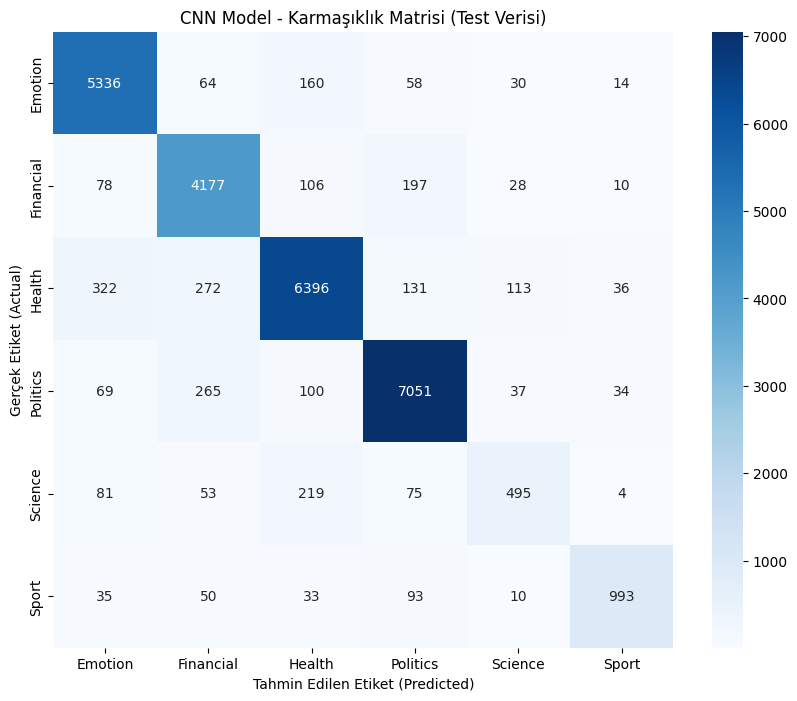


--- Adım 8 (Değerlendirme) tamamlandı. ---


In [12]:
# ==========================================================
# ADIM 8: Modelin Değerlendirilmesi (Test Verisi Üzerinde)
# ==========================================================
# Bu adım, hocanın kodundaki "===== EVALUATION =====" bölümüne karşılık gelir.
# Sizin Naive Bayes kodunuzdaki 'classification_report' ve 'confusion_matrix'
# adımlarına benzer detaylı bir rapor da ekleyelim.

# sklearn metrikleri için
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

try:
    print(f"Adım 8: Model '{device}' cihazında test verisi üzerinde değerlendiriliyor...")

    # Modeli "değerlendirme modu"na al (Dropout'u kapatır)
    model.eval()

    all_predictions = []
    all_true_labels = []

    # Gradyan hesaplamalarını durdur (hafızadan tasarruf sağlar)
    with torch.no_grad():
        # Adım 5'te oluşturulan 'test_loader' ile verileri gez
        for texts_batch, labels_batch in test_loader:

            # Veriyi modele uygun cihaza taşı ('cpu' veya 'cuda')
            texts_batch = texts_batch.to(device)
            labels_batch = labels_batch.to(device)

            # 1. Tahmin (Forward Pass)
            outputs = model(texts_batch)

            # 2. Tahmin edilen sınıfı al (en yüksek skorlu olan)
            _, predicted = torch.max(outputs, 1)

            # Raporlama için tahminleri ve gerçek etiketleri topla
            # .cpu() ile veriyi GPU'dan (varsa) CPU'ya geri al
            all_predictions.extend(predicted.cpu().numpy())
            all_true_labels.extend(labels_batch.cpu().numpy())

    print("Değerlendirme tamamlandı.")
    print("\n" + "="*50 + "\n")

    # --- Sonuç Raporlaması (Sizin NB kodunuza benzer) ---

    # 1. Genel Doğruluk (Accuracy)
    test_accuracy = accuracy_score(all_true_labels, all_predictions)
    print("Model Performans Raporu (Test Verisi):")
    print(f"Genel Doğruluk (Accuracy): {test_accuracy:.4f} (Tahminlerin %{test_accuracy*100:.2f}'si doğru)")
    print("\n" + "-"*50 + "\n")

    # 2. Detaylı Sınıflandırma Raporu
    # Adım 3+4'te oluşturduğumuz 'label_to_int' sözlüğünü kullanarak
    # 0, 1, 2... gibi sayıları 'Politics', 'Sport' gibi isimlere geri çevirelim
    target_names = [label for label, i in sorted(label_to_int.items(), key=lambda item: item[1])]

    print(f"Detaylı Sınıflandırma Raporu ({num_classes} Sınıf):")
    print(classification_report(all_true_labels, all_predictions, target_names=target_names))
    print("\n" + "-"*50 + "\n")

    # 3. Karmaşıklık Matrisi (Confusion Matrix)
    print("Karmaşıklık Matrisi (Confusion Matrix):")
    print("(Satırlar: Gerçek Etiket, Sütunlar: Tahmin Edilen Etiket)")

    cm = confusion_matrix(all_true_labels, all_predictions)

    # Heatmap'i çizdiriyoruz (6x6 olacak)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Tahmin Edilen Etiket (Predicted)')
    plt.ylabel('Gerçek Etiket (Actual)')
    plt.title('CNN Model - Karmaşıklık Matrisi (Test Verisi)')
    plt.show()

    print("\n--- Adım 8 (Değerlendirme) tamamlandı. ---")


except NameError as e:
    print("\n--- HATA ---")
    print(f"'{e.name}' değişkeni tanımlanmamış görünüyor.")
    print("Bu bloğu çalıştırmadan önce Adım 5 ve 6'yı başarıyla çalıştırdığınızdan emin olun.")
except Exception as e:
    print(f"\nBir hata oluştu: {e}")